## Part 1: Pulse Rate Algorithm

### Contents
Fill out this notebook as part of your final project submission.

**You will have to complete both the Code and Project Write-up sections.**
- The [Code](#Code) is where you will write a **pulse rate algorithm** and already includes the starter code.
   - Imports - These are the imports needed for Part 1 of the final project. 
     - [glob](https://docs.python.org/3/library/glob.html)
     - [numpy](https://numpy.org/)
     - [scipy](https://www.scipy.org/)
- The [Project Write-up](#Project-Write-up) to describe why you wrote the algorithm for the specific case.


### Dataset
You will be using the **Troika**[1] dataset to build your algorithm. Find the dataset under `datasets/troika/training_data`. The `README` in that folder will tell you how to interpret the data. The starter code contains a function to help load these files.

1. Zhilin Zhang, Zhouyue Pi, Benyuan Liu, ‘‘TROIKA: A General Framework for Heart Rate Monitoring Using Wrist-Type Photoplethysmographic Signals During Intensive Physical Exercise,’’IEEE Trans. on Biomedical Engineering, vol. 62, no. 2, pp. 522-531, February 2015. Link

-----

### Code

In [3]:
import glob

import numpy as np
import scipy as sp
import scipy.io
import scipy.signal


def LoadTroikaDataset():
    """
    Retrieve the .mat filenames for the troika dataset.

    Review the README in ./datasets/troika/ to understand the organization of the .mat files.

    Returns:
        data_fls: Names of the .mat files that contain signal data
        ref_fls: Names of the .mat files that contain reference data
        <data_fls> and <ref_fls> are ordered correspondingly, so that ref_fls[5] is the 
            reference data for data_fls[5], etc...
    """
    data_dir = "./datasets/troika/training_data"
    data_fls = sorted(glob.glob(data_dir + "/DATA_*.mat"))
    ref_fls = sorted(glob.glob(data_dir + "/REF_*.mat"))
    return data_fls, ref_fls

def LoadTroikaDataFile(data_fl):
    """
    Loads and extracts signals from a troika data file.

    Usage:
        data_fls, ref_fls = LoadTroikaDataset()
        ppg, accx, accy, accz = LoadTroikaDataFile(data_fls[0])

    Args:
        data_fl: (str) filepath to a troika .mat file.

    Returns:
        numpy arrays for ppg, accx, accy, accz signals.
    """
    data = sp.io.loadmat(data_fl)['sig']
    return data[2:]


def AggregateErrorMetric(pr_errors, confidence_est):
    """
    Computes an aggregate error metric based on confidence estimates.

    Computes the MAE at 90% availability. 

    Args:
        pr_errors: a numpy array of errors between pulse rate estimates and corresponding 
            reference heart rates.
        confidence_est: a numpy array of confidence estimates for each pulse rate
            error.

    Returns:
        the MAE at 90% availability
    """
    # Higher confidence means a better estimate. The best 90% of the estimates
    #    are above the 10th percentile confidence.
    percentile90_confidence = np.percentile(confidence_est, 10)

    # Find the errors of the best pulse rate estimates
    best_estimates = pr_errors[confidence_est >= percentile90_confidence]

    # Return the mean absolute error
    return np.mean(np.abs(best_estimates))

def Evaluate():
    """
    Top-level function evaluation function.

    Runs the pulse rate algorithm on the Troika dataset and returns an aggregate error metric.

    Returns:
        Pulse rate error on the Troika dataset. See AggregateErrorMetric.
    """
    # Retrieve dataset files
    data_fls, ref_fls = LoadTroikaDataset()
    errs, confs = [], []
    for data_fl, ref_fl in zip(data_fls, ref_fls):
        # Run the pulse rate algorithm on each trial in the dataset
        errors, confidence = RunPulseRateAlgorithm(data_fl, ref_fl)
        errs.append(errors)
        confs.append(confidence)
        # Compute aggregate error metric
    errs = np.hstack(errs)
    confs = np.hstack(confs)
    return AggregateErrorMetric(errs, confs)

def find_frequency_peaks(fft_mags, fft_freqs, bandpass):
    """
    Find peak indices of frequencies.

    Args:
        fft_mags: a numpy array of FFT magnitudes of a signal
        fft_freqs: a numpy array of the corresponding frequency values
        bandpass: a tuple of frequency bandpass

    Returns:
        peaks: a list of tuples of peaks' magnitude and frequency, sorted by magnitude
    """
    lf, hf = bandpass
    min_height = 1.5 * np.mean(fft_mags[(fft_freqs > lf) & (fft_freqs < hf)]) # Mean of magnitudes within the bandpass
    f_distance = 2 # Corresponding to 0.125 Hz (7.5 BPM) minimum distance between peaks

    # Get peaks
    peak_locs = sp.signal.find_peaks(fft_mags, height=min_height, distance=f_distance)[0]
    peak_mags = fft_mags[peak_locs]
    peak_f = fft_freqs[peak_locs]
    peaks = sorted(list(zip(peak_mags, peak_f)), reverse=True)

    return peaks
    

def RunPulseRateAlgorithm(data_fl, ref_fl):
    """
    Running pulse-rate estimation algorithm on the input data
    and returning error and confidence for each estimations.

    Args:
        data_fl: a string of where the data file is saved
        ref_fl: a string of where the reference file is saved

    Returns:
        errors: a numpy array containing pulse-rate estimates
                for each window of time
        confidence: a numpy array containing each estimate's confidence
    """
    # Load data using LoadTroikaDataFile
    ppg, accx, accy, accz = LoadTroikaDataFile(data_fl)
    ppg -= np.mean(ppg)
    accx -= np.mean(accx)
    accy -= np.mean(accy)
    accz -= np.mean(accz)
    ref = np.hstack(sp.io.loadmat(ref_fl)['BPM0'])
    fs = 125
    
    # 40-240 BPM Bandpass Filter
    low = 40 / 60 # Hz
    high = 240 / 60 # Hz
    band = (low, high)
    b, a = sp.signal.butter(N=3, Wn=band, btype='bandpass', fs=fs)
    ppg = sp.signal.filtfilt(b, a, ppg)
    accx = sp.signal.filtfilt(b, a, accx)
    accy = sp.signal.filtfilt(b, a, accy)
    accz = sp.signal.filtfilt(b, a, accz)

    # Rolling the window
    preds = list()
    confidences = list()
    n_window = 8 * fs # 8 seconds
    n_sliding = 2 * fs # 2 seconds
    prev_pred = None

    for i in range(0, len(ppg) - n_window + 1, n_sliding):
        window_ppg = ppg[i:i+n_window]
        window_accx = accx[i:i+n_window]
        window_accy = accy[i:i+n_window]
        window_accz = accz[i:i+n_window]
        
        # Obtain frequency domain of signals
        freqs = np.fft.rfftfreq(n_window, d=1/fs)
        ppg_fft = abs(np.fft.rfft(window_ppg))
        accx_fft = abs(np.fft.rfft(window_accx))
        accy_fft = abs(np.fft.rfft(window_accy))
        accz_fft = abs(np.fft.rfft(window_accz))

        # Zero-ing frequencies outside bandpass
        ppg_fft[(freqs < low) | (freqs > high)] = 0
        accx_fft[(freqs < low) | (freqs > high)] = 0
        accy_fft[(freqs < low) | (freqs > high)] = 0
        accz_fft[(freqs < low) | (freqs > high)] = 0

        # Get PPG peaks
        ppg_peaks = find_frequency_peaks(ppg_fft, freqs, (low, high))

        # Get prediction
        f_tol = 5 / 60 # 5 BPM tolerance window
        pred = ppg_peaks[0][1] # Default prediction, greatest PPG frequency


        # If PPG peak is similar to accel's and their harmonics, while PPG peaks are more than 1
        peak_accx = freqs[np.argmax(accx_fft)]
        peak_accy = freqs[np.argmax(accy_fft)]
        peak_accz = freqs[np.argmax(accz_fft)]
        
        if ((abs(pred-peak_accx) <= f_tol) or
            (abs(pred-peak_accy) <= f_tol) or
            (abs(pred-peak_accz) <= f_tol)) and len(ppg_peaks) > 1:
            pred = ppg_peaks[1][1]
            ppg_peaks = ppg_peaks[1:] # Remove the frequency from smoothing candidates

        # Smoothing by getting the best candidate that's nearest to the previous predicted pulse-rate
        candidates = [f for _, f in ppg_peaks[:5]]

        if prev_pred is None:
            pred = candidates[0]
        else:
            pred = min(candidates, key=lambda f: abs(f - prev_pred))

        prev_pred = pred        
        pred_bpm = pred * 60 # Convert to beats-per-minute (BPM)
        preds.append(pred_bpm)

        # Get Confidence as signal-to-noise-ratio (SNR)
        f_loc = (freqs > pred-f_tol) & (freqs < pred+f_tol)
        signal_power = ppg_fft[f_loc].sum()
        snr = signal_power / ppg_fft.sum()
        confidences.append(snr)

    # Return per-estimate mean absolute error and confidence as a 2-tuple of numpy arrays.
    errors = abs(preds - ref)
    confidence = np.array(confidences)
    return errors, confidence

-----
### Project Write-up

Answer the following prompts to demonstrate understanding of the algorithm you wrote for this specific context.

> - **Code Description** - Include details so someone unfamiliar with your project will know how to run your code and use your algorithm. 
> - **Data Description** - Describe the dataset that was used to train and test the algorithm. Include its short-comings and what data would be required to build a more complete dataset.
> - **Algorithhm Description** will include the following:
>   - how the algorithm works
>   - the specific aspects of the physiology that it takes advantage of
>   - a describtion of the algorithm outputs
>   - caveats on algorithm outputs 
>   - common failure modes
> - **Algorithm Performance** - Detail how performance was computed (eg. using cross-validation or train-test split) and what metrics were optimized for. Include error metrics that would be relevant to users of your algorithm. Caveat your performance numbers by acknowledging how generalizable they may or may not be on different datasets.

Your write-up goes here...

### Code Description

- In order to run the code in this notebook, make sure you have the followings Python's library installed in your environment:
    - Numpy
    - Pandas
    - Scipy version 1.2.0+
- For running the algorithm on individual file, run `RunPulseRateAlgorithm(data_fl, ref_fl)` with `data_fl` argument being where the data file is saved, and `ref_fl` argument being where the reference file for the data is saved.
- To evaluate the algorithm by obtaining the mean-absolute-error (MAE) on the whole dataset with 90% availability, run `Evaluate()`.

### Data Description

The dataset used to test the algorithm is the TROIKA dataset, containing 6 channels signals from 12 subjects with age from 18 to 35. The 6 channels are: EKG, PPG-1, PPG-2, X-Axis Accelerometer, Y-Axis Accelerometer, and Z-Axis Accelerometer. All signals were sample at the rate of 125 Hz.

From all the 6 channels available, the channels used in the algorithm are the PPG-2 and the 3 accelerometers'.

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

In [44]:
data_fls, ref_fls = LoadTroikaDataset()

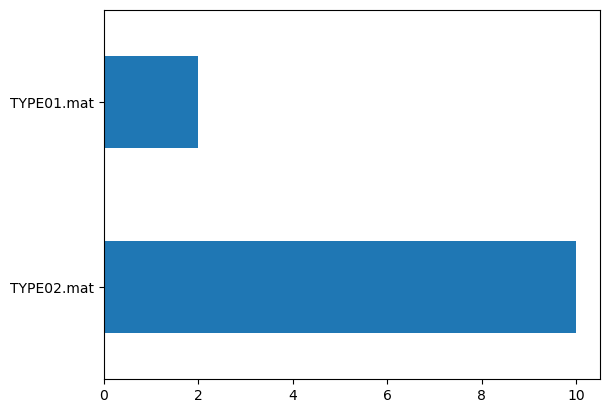

In [58]:
# Type distribution
types = pd.Series([f.split('/')[-1].split('_')[-1] for f in data_fls])
types.value_counts().plot.barh();

There are two types of data in the dataset: `TYPE01` and `TYPE02`. They differ in the speed of the treadmill of which the data was obtained with. Observing the distribution of the types portrayed above, there is an imbalance between the quantity of these two types in the dataset: `TYPE02` accounts for 83% of the dataset.

Data imbalance such as this may pose a bias in the model/algorithm. For one, since `TYPE02` consists of lower treadmill-speed data, the model may perform worse on data with higher treadmill-speed.

In order to overcome this shortcoming, several actions may be taken:
- Record more data for `TYPE01`
- Perform data augmentation for `TYPE01` data with methods that are specific to time-series or signal data
- When using machine learning models, set the training parameter of the model to adjust for imbalance in the data

### Algorithm Description

Here is the steps of what being performed by the algorithm:
1. Obtain signals from channel 2, 3, 4, and 5 corresponding to PPG-2, Acc-X, Acc-Y, and Acc-Z.
2. Substract means from the signals to center them around 0.
3. Perform bandpass-filter from 40-240 Hz to all signals.
4. Rolling window with window-length of 8s and 2s step for each signal:
    1.  Perform fourier-transform on each of the signal
    2.  Get most dominant frequency of PPG for default prediction
    3.  Check if the most dominant frequencies from the accelerometers overlap that of the PPG's
    4.  If yes, get the next dominant frequency of the PPG
    5.  Perform smoothing by comparing current prediction from the previous': get the smallest difference from the previous prediction, of the dominant frequencies.

In essence, it tries to obtain pulse-rate estimation by observing dominant frequencies existing from the PPG signals. Since PPG signal measures the rate of LED light absorption in the blood, its rise and fall corresponds to blood's concentration being low and high, which is caused by the blood being pumped by the heart. This rate of change in blood's concentration is what the algorithm tries to find, since it is caused by the pumping rate of the heart, and thus pulse/heart-rate.

The output of the algorithm is the predicted pulse-rate in BPM and its corresponding confidence level. Because of this confidence level, the caveat of using it to find the best prediction might not always correspond to a good MAE. A prediction might have a low MAE (thus a good prediction), but low SNR.

The problem of confidence level not always being a good measure of prediction is observed by changing the definition of the confidence level by just the negative of the MAEs (low gets high confidence, vice versa). Doing this increases the overall performance of MAE over the 90% availabile data significantly, which is why the future work on this project should revisit SNR as the means of getting the confidence value.

### Algorithm Performance

The algorithm is mainly measured and optimised against Mean Absolute Error (MAE):

$$
\mathrm{MAE} = \frac{1}{N}\sum_{i=1}^{N}\left| \widehat{\mathrm{BPM}}_i - \mathrm{BPM}_i \right|
$$


The measure MAE is obtained from data with 90% availability. This availability come from the top 90% data-points in confidence.

Confidence is obtained by calculating the Signal-to-Noise-Ratio (SNR) of each prediction, based on the energy ratio of the predicted-frequency over the others.

$$
\mathrm{SNR} = \frac{P_{\mathrm{signal}}}{P_{\mathrm{total}}}
$$


In [4]:
Evaluate()

np.float64(23.07123000866402)

As observed above, the overall MAE from data with 90% availability is 23.07. The algorithm performs better when tested against the the test-dataset from the classroom's workspace, of which the algorithm got 5.87 MAE:

<p align="center">
<img src="passed.png">
</p>

The low MAE result obtained from the test dataset might not be replicable when tested against different composition of the dataset split. This is why it is important in the future to perform Cross-Validation (CV) instead of just one test-dataset.

-----
### Next Steps
You will now go to **Test Your Algorithm** (back in the Project Classroom) to apply a unit test to confirm that your algorithm met the success criteria. 